# 3. Обучение Transformer-классификатора и оценка

Обучаем Transformer с нуля для классификации подкатегорий Sports.

Вход: последовательность текстовых эмбеддингов (чанки субтитров видео).
Выход: класс подкатегории.

In [1]:

import sys
sys.path.append("..")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import json
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

from src.model import TransformerClassifier
from src.dataset import SportsEmbeddingDataset
from src.utils import compute_metrics, plot_confusion_matrix, plot_training_history
from src.validation import collect_artifact_report, format_artifact_report

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


c:\Users\Пользователь\.pyenv\pyenv-win\versions\3.10.4\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 3.1 Загрузка данных

In [2]:

# 3.1 Загрузка данных и fail-fast проверка артефактов
report = collect_artifact_report(DATA_DIR)
print(format_artifact_report(report))
if not report.embeddings_match_parquets:
    raise ValueError(
        "embeddings.npz не соответствует train/val/test parquet. "
        "Перезапустите notebooks/02_embedding_extraction.ipynb после подготовки данных."
    )

data = np.load(DATA_DIR / "embeddings.npz")
train_emb, train_labels, train_lens = data["train_emb"], data["train_labels"], data["train_lens"]
val_emb, val_labels, val_lens = data["val_emb"], data["val_labels"], data["val_lens"]
test_emb, test_labels, test_lens = data["test_emb"], data["test_labels"], data["test_lens"]

# Labels уже должны быть 0..N-1, но оставляем защитный remap на случай внешних артефактов.
unique_labels = sorted(np.unique(np.concatenate([train_labels, val_labels, test_labels])))
label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_orig = {i: lbl for lbl, i in label_to_idx.items()}

train_labels = np.array([label_to_idx[l] for l in train_labels])
val_labels = np.array([label_to_idx[l] for l in val_labels])
test_labels = np.array([label_to_idx[l] for l in test_labels])

num_classes = len(unique_labels)
print(f"Original labels: {unique_labels} -> Mapped to: {list(range(num_classes))}")

with open(DATA_DIR / "id2label.json", encoding="utf-8") as f:
    id2label_raw = json.load(f)

class_names = [id2label_raw.get(str(idx_to_orig[i]), f"Class_{idx_to_orig[i]}") for i in range(num_classes)]
id2label = {str(i): name for i, name in enumerate(class_names)}

print(f"Train: {train_emb.shape}, Val: {val_emb.shape}, Test: {test_emb.shape}")
print(f"Num classes: {num_classes}")
print(f"Classes: {class_names}")


Dataset artifact report
captions: 15,976 lines, 15,976 unique ids, 0 duplicates, 0 bad lines
parquets: {'train': 11183, 'val': 2396, 'test': 2397} total=15,976
embeddings: {'train': 11183, 'val': 2396, 'test': 2397} total=15,976
embeddings match parquets: True
Original labels: [0, 1, 2, 3] -> Mapped to: [0, 1, 2, 3]
Train: (11183, 10, 384), Val: (2396, 10, 384), Test: (2397, 10, 384)
Num classes: 4
Classes: ['Individual Sports', 'Outdoor Recreation', 'Personal Fitness', 'Team Sports']


In [3]:

MAX_SEQ_LEN = cfg["model"]["max_seq_len"]
BATCH_SIZE = cfg["training"]["batch_size"]

train_ds = SportsEmbeddingDataset(train_emb, train_labels, train_lens, max_seq_len=MAX_SEQ_LEN)
val_ds = SportsEmbeddingDataset(val_emb, val_labels, val_lens, max_seq_len=MAX_SEQ_LEN)
test_ds = SportsEmbeddingDataset(test_emb, test_labels, test_lens, max_seq_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch embeddings: {batch['embeddings'].shape}")
print(f"Batch mask: {batch['mask'].shape}")
print(f"Batch labels: {batch['label'].shape}")
print(f"Masked positions in first batch: {batch['mask'].sum().item()}")


Batch embeddings: torch.Size([32, 15, 384])
Batch mask: torch.Size([32, 15])
Batch labels: torch.Size([32])
Masked positions in first batch: 169


## 3.2 Модель

In [4]:
model = TransformerClassifier(
    num_classes=num_classes,
    d_model=cfg["model"]["d_model"],
    nhead=cfg["model"]["nhead"],
    num_encoder_layers=cfg["model"]["num_encoder_layers"],
    dim_feedforward=cfg["model"]["dim_feedforward"],
    dropout=cfg["model"]["dropout"],
    max_seq_len=MAX_SEQ_LEN,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:\n{model}")


Total parameters: 1,680,644
Trainable parameters: 1,680,644

Architecture:
TransformerClassifier(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (linear1): Linear(in_features=384, out_features=256, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=256, out_features=384, bias=True)
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.4, inplace=False)
        (dropout2): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    (1):

## 3.3 Обучение

In [5]:

EPOCHS = cfg["training"]["epochs"]
LR = cfg["training"]["learning_rate"]
WEIGHT_DECAY = cfg["training"]["weight_decay"]

class_counts = np.bincount(train_labels, minlength=num_classes).astype(np.float32)
if cfg["training"].get("class_weighting") == "sqrt_inverse_frequency":
    class_weights_np = np.sqrt(class_counts.max() / class_counts)
    class_weights_np = class_weights_np / class_weights_np.mean()
else:
    class_weights_np = np.ones(num_classes, dtype=np.float32)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

print("Class counts:", dict(zip(class_names, class_counts.astype(int).tolist())))
print("Class weights:", dict(zip(class_names, [round(float(w), 4) for w in class_weights_np])))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        emb = batch["embeddings"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(emb, src_key_padding_mask=mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for batch in loader:
        emb = batch["embeddings"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(emb, src_key_padding_mask=mask)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return total_loss / total, correct / total, macro_f1, all_preds, all_labels, all_probs

print("Training functions defined")


Class counts: {'Individual Sports': 2892, 'Outdoor Recreation': 6197, 'Personal Fitness': 278, 'Team Sports': 1816}
Class weights: {'Individual Sports': 0.6483, 'Outdoor Recreation': 0.4428, 'Personal Fitness': 2.0908, 'Team Sports': 0.8181}
Training functions defined


In [6]:

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_macro_f1 = -1
best_val_acc = -1
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_macro_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} MacroF1: {val_macro_f1:.4f} | LR: {lr:.6f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pt")
        print(f"  -> New best model saved (val_macro_f1={val_macro_f1:.4f})")

print(f"\nBest validation macro F1: {best_val_macro_f1:.4f} at epoch {best_epoch}")


Epoch 01/50 | Train Loss: 0.8684 Acc: 0.6872 | Val Loss: 0.6654 Acc: 0.6945 MacroF1: 0.6938 | LR: 0.000999
  -> New best model saved (val_macro_f1=0.6938)
Epoch 02/50 | Train Loss: 0.7562 Acc: 0.7280 | Val Loss: 0.5984 Acc: 0.7550 MacroF1: 0.7284 | LR: 0.000996
  -> New best model saved (val_macro_f1=0.7284)
Epoch 03/50 | Train Loss: 0.7288 Acc: 0.7366 | Val Loss: 0.6323 Acc: 0.7909 MacroF1: 0.7539 | LR: 0.000991
  -> New best model saved (val_macro_f1=0.7539)
Epoch 04/50 | Train Loss: 0.6851 Acc: 0.7527 | Val Loss: 0.6061 Acc: 0.7884 MacroF1: 0.7475 | LR: 0.000984
Epoch 05/50 | Train Loss: 0.6808 Acc: 0.7544 | Val Loss: 0.5914 Acc: 0.7871 MacroF1: 0.7632 | LR: 0.000976
  -> New best model saved (val_macro_f1=0.7632)
Epoch 06/50 | Train Loss: 0.6884 Acc: 0.7574 | Val Loss: 0.6524 Acc: 0.7922 MacroF1: 0.7452 | LR: 0.000965
Epoch 07/50 | Train Loss: 0.6775 Acc: 0.7587 | Val Loss: 0.5768 Acc: 0.7884 MacroF1: 0.7629 | LR: 0.000952
Epoch 08/50 | Train Loss: 0.6610 Acc: 0.7658 | Val Loss: 0.

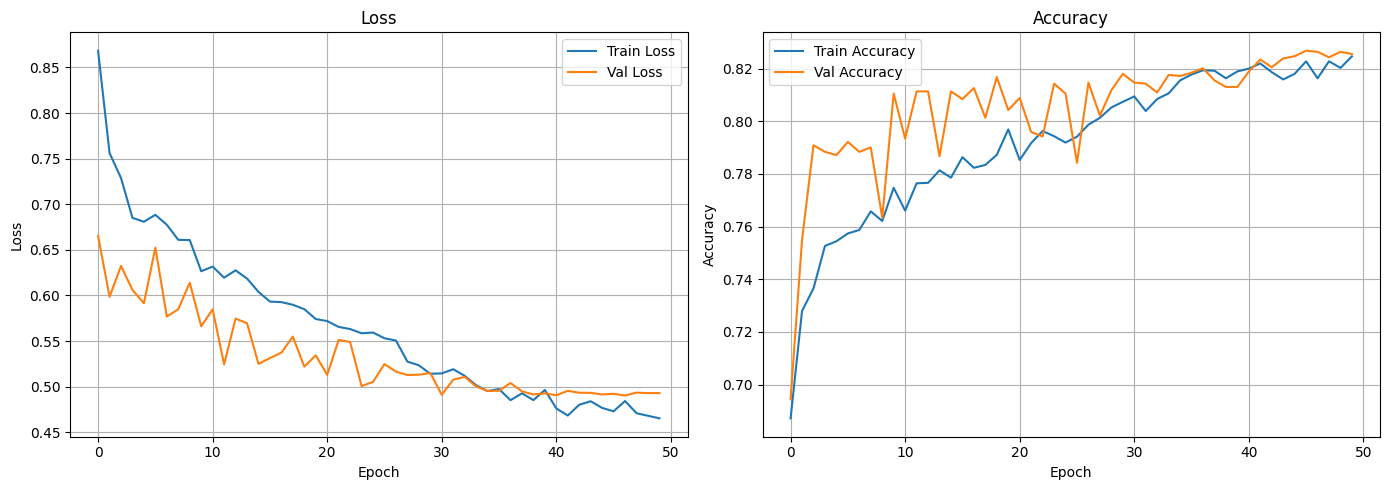

In [7]:
fig = plot_training_history(train_losses, val_losses, train_accs, val_accs)
fig.savefig(OUTPUT_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.4 Оценка на тестовом наборе

In [8]:

model.load_state_dict(torch.load(OUTPUT_DIR / "best_model.pt", map_location=device))

test_loss, test_acc, test_macro_f1, test_preds, test_true, test_probs = evaluate(
    model, test_loader, criterion, device
)

metrics = compute_metrics(test_true, test_preds, test_probs, k=min(3, num_classes))

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)
for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")


TEST RESULTS
  accuracy: 0.8231
  f1_macro: 0.7852
  f1_weighted: 0.8227
  precision_macro: 0.8249
  recall_macro: 0.7580
  top_3_accuracy: 0.9921


In [9]:
from sklearn.metrics import classification_report

print(classification_report(test_true, test_preds, target_names=class_names))


                    precision    recall  f1-score   support

 Individual Sports       0.76      0.78      0.77       620
Outdoor Recreation       0.86      0.87      0.87      1328
  Personal Fitness       0.90      0.63      0.74        59
       Team Sports       0.77      0.75      0.76       390

          accuracy                           0.82      2397
         macro avg       0.82      0.76      0.79      2397
      weighted avg       0.82      0.82      0.82      2397



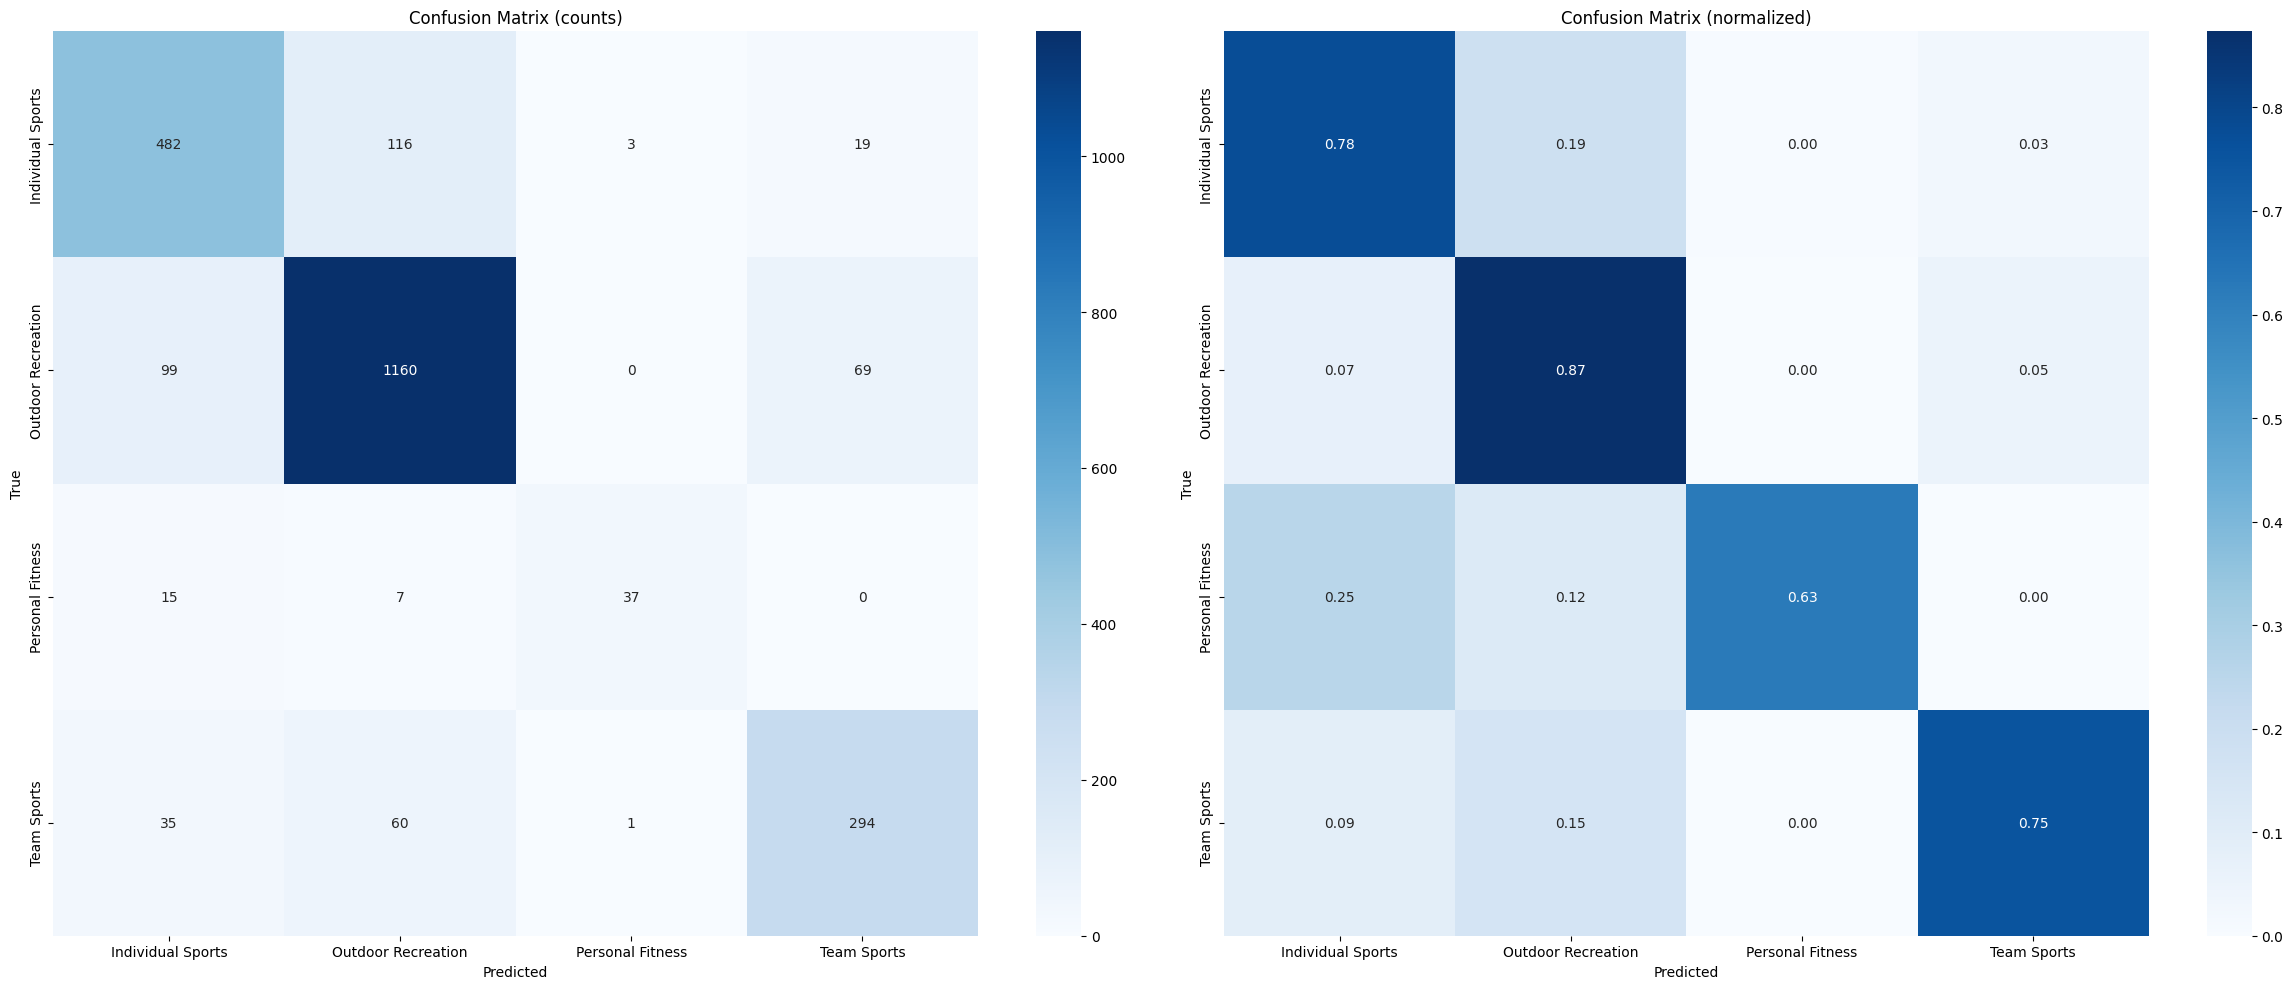

In [10]:
fig = plot_confusion_matrix(test_true, test_preds, class_names, figsize=(12, 10))
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 3.5 Анализ ошибок

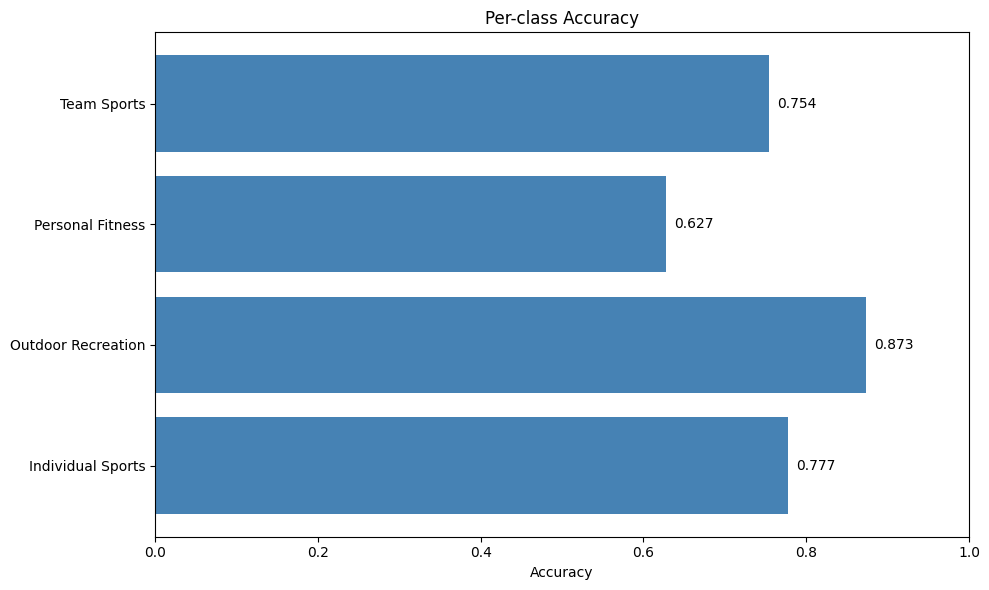

In [11]:
# Per-class accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_true, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(class_names, per_class_acc, color="steelblue")
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Per-class Accuracy")
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{acc:.3f}", va="center")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# Наиболее частые ошибки
errors = []
for i in range(len(test_true)):
    if test_true[i] != test_preds[i]:
        errors.append((class_names[test_true[i]], class_names[test_preds[i]]))

from collections import Counter
error_counts = Counter(errors).most_common(10)

print("Top-10 most common misclassifications:")
print(f"{'True':>25s} -> {'Predicted':<25s} Count")
print("-" * 60)
for (true_cls, pred_cls), count in error_counts:
    print(f"{true_cls:>25s} -> {pred_cls:<25s} {count}")


Top-10 most common misclassifications:
                     True -> Predicted                 Count
------------------------------------------------------------
        Individual Sports -> Outdoor Recreation        116
       Outdoor Recreation -> Individual Sports         99
       Outdoor Recreation -> Team Sports               69
              Team Sports -> Outdoor Recreation        60
              Team Sports -> Individual Sports         35
        Individual Sports -> Team Sports               19
         Personal Fitness -> Individual Sports         15
         Personal Fitness -> Outdoor Recreation        7
        Individual Sports -> Personal Fitness          3
              Team Sports -> Personal Fitness          1


## 3.6 Сохранение результатов

In [13]:

results = {
    "config": cfg,
    "training_variant": "transformer_weighted_sqrt_inverse_frequency_best_macro_f1",
    "device": str(device),
    "num_classes": num_classes,
    "class_names": class_names,
    "class_counts": {class_names[i]: int(class_counts[i]) for i in range(num_classes)},
    "class_weights": {class_names[i]: float(class_weights_np[i]) for i in range(num_classes)},
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "test_loss": float(test_loss),
    "best_val_macro_f1": float(best_val_macro_f1),
    "best_val_acc": float(best_val_acc),
    "best_epoch": int(best_epoch),
    "epochs_trained": len(train_losses),
    "total_params": total_params,
}

with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'best_model.pt'}")
print(f"  {OUTPUT_DIR / 'results.json'}")
print(f"  {OUTPUT_DIR / 'training_history.png'}")
print(f"  {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"  {OUTPUT_DIR / 'per_class_accuracy.png'}")
print("\nDone!")


Saved:
  ..\outputs\best_model.pt
  ..\outputs\results.json
  ..\outputs\training_history.png
  ..\outputs\confusion_matrix.png
  ..\outputs\per_class_accuracy.png

Done!
